In [1]:
%load_ext autoreload
%autoreload 2

# Эксперимент 1: DiffusionAE

Берем за основу [Time-RCD](https://github.com/thu-sail-lab/Time-RCD/blob/tsb-ad-integration/training.py). В статье она последовательно обучается на большом количестве различных наборов данных последовательно (перенося веса между датасетами). В этом эксперименте обучим просто на наборе данных, предложенных в [DiffusionAE](https://github.com/fbrad/DiffusionAE/tree/main).

In [2]:
import os
import sys
import glob
import json
import shutil
import subprocess
from datetime import datetime

sys.path.append("..")

import torch
import numpy as np

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
assert device == "cuda"

DATA_DIR = "../data/DiffusionAE"
TIME_NOW = datetime.now().strftime('%Y%m%d-%H%M')

os.makedirs(DATA_DIR, exist_ok=True)

In [4]:
from src import TrainingConfig


training_config = TrainingConfig(
    max_seq_len=256,
    overlap_ratio=0.0,
    accumulation_steps=3,
    alpha=1.0,
    learning_rate=1e-4, # Appendix, D.4 -- 5e-4
    weight_decay=1e-5,
    batch_size=32,
    num_epochs=100, # Appendix, D.4 -- максимум 50 эпох
    enable_ts_train=True,
    mixed_precision=True,
    checkpoint_dir=None,
    checkpoint_step=50,
    early_stopping_patience=50,
    verbose=1,
)

training_config.to_dict()

{'batch_size': 32,
 'learning_rate': 0.0001,
 'num_epochs': 100,
 'max_seq_len': 256,
 'overlap_ratio': 0.0,
 'accumulation_steps': 3,
 'alpha': 1.0,
 'weight_decay': 1e-05,
 'enable_ts_train': True,
 'mixed_precision': True,
 'seed': 72,
 'checkpoint_dir': None,
 'checkpoint_step': 50,
 'early_stopping_patience': 50,
 'verbose': 1}

In [5]:
from src import DetectorConfig

# Архитектура ровно как в статье https://arxiv.org/pdf/2509.21190, Appendix D.4
detector_config = DetectorConfig(
    patch_size=16,
    d_model=512,
    d_proj=256,
    num_layers=8,
    num_heads=8,
    num_features=5,
    use_anomaly_head=False,
)

detector_config.to_dict()

{'d_model': 512,
 'd_proj': 256,
 'patch_size': 16,
 'num_query_tokens': 1,
 'num_layers': 8,
 'num_heads': 8,
 'd_ff_dropout': 0.1,
 'use_rope': True,
 'activation': 'gelu',
 'num_features': 5,
 'use_anomaly_head': False}

In [6]:
ANOMALY_KEY = "logits"

## Модель

In [7]:
from src import Detector

detector = Detector(detector_config)
detector

Detector(
  (ts_encoder): TimeSeriesEncoder(
    (embedding_layer): Linear(in_features=16, out_features=512, bias=True)
    (rope_embedder): RoPELayer()
    (transformer_encoder): CustomTransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayerWithRoPE(
          (self_attn): MultiheadAttentionWithRoPE(
            (q_proj): Linear(in_features=512, out_features=512, bias=False)
            (k_proj): Linear(in_features=512, out_features=512, bias=False)
            (v_proj): Linear(in_features=512, out_features=512, bias=False)
            (out_proj): Linear(in_features=512, out_features=512, bias=False)
            (binary_attention_bias): BinaryAttentionBias(
              (emd): Embedding(2, 8)
            )
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (input_norm): RMSNorm((512,), eps=None, elementwise_affine=True)
          (output_norm): RMSNorm((512,), eps=None, elementwise_affine=True)
          (mlp): LlamaMLP(
       

In [8]:
print(sum(p.numel() for p in detector.parameters()))
del detector

37023361


## Загрузка данных

In [9]:
# subprocess.run([
#     'git', 'clone', 'https://github.com/fbrad/DiffusionAE.git', f"{DATA_DIR}/tmp_repo"
# ], check=True)
# shutil.copytree(f'{DATA_DIR}/tmp_repo/DiffusionAE/processed', DATA_DIR, dirs_exist_ok=True)
# shutil.rmtree(f"{DATA_DIR}/tmp_repo/")

## Формат данных

https://arxiv.org/pdf/2311.01452

**Синтетика**

| Dataset    | Anomaly type | Train     | Valid  | Test    | \|D\| | Anomalies in train | Anomalies in test |
|------------|--------------|-----------|--------|---------|-------|--------------------|-------------------|
| Global     | point        | 20,000    | 10,000 | 20,000  | 5     | +                  | 6%                |
| Contextual | point        | 20,000    | 10,000 | 20,000  | 5     | +                  | 6%                |
| Seasonal   | point        | 20,000    | 10,000 | 20,000  | 5     | +                  | 6%                |
| Shapelet   | point        | 20,000    | 10,000 | 20,000  | 5     | +                  | 5%                |
| Trend      | pattern      | 20,000    | 10,000 | 20,000  | 5     | +                  | 6%                |

Синтезировано по 50к наблюдений в каждом. Размерность везде 5, но аномалии содержит лишь одна из них. Выборки стратифицированы по доле анормальности.

**Реальные**

| Dataset    | Anomaly type | Train     | Valid  | Test    | \|D\| | Anomalies in train | Anomalies in test |
|------------|--------------|-----------|--------|---------|-------|--------------------|-------------------|
| SWaT       | pattern      | 495,000   | 44,991 | 404,928 | 51    | -                  | 12.38%            |
| WADI       | pattern      | 1,048,571 | 30,000 | 142,801 | 123   | -                  | 5.77%             |

Разные доли в валидации:
* **SWaT**: 5.79% на валидации, 5.77% на тесте
* **WADI**: 9.93% на валидации, 12.38% на тесте

## Подготовка данных

In [10]:
from src import get_DAE_loaders

FOLDERS = glob.glob(f"{DATA_DIR}/*") #[1:2]
loaders = {
    os.path.split(fld)[-1]: get_DAE_loaders(fld, training_config)
    for fld in FOLDERS
}

pattern_seasonal
    X_train: (78, 256, 5)
    y_train: (78, 256)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
pattern_shapelet
    X_train: (78, 256, 5)
    y_train: (78, 256)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
pattern_trendv2
    X_train: (78, 256, 5)
    y_train: (78, 256)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
point_contextual
    X_train: (78, 256, 5)
    y_train: (78, 256)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)
point_global
    X_train: (78, 256, 5)
    y_train: (78, 256)
    X_valid: (39, 256, 5)
    y_valid: (39, 256)
     X_test: (78, 256, 5)


## Обучение

In [11]:
from src import (
    train_worker,
    plot_training_results,
)

from tensorboard_utils import (
    init_tensorboard,
    log_losses,
)

In [12]:
# from src import train_epoch

# detector = Detector(detector_config).to(device)
# optimizer = torch.optim.AdamW(
#     detector.parameters(),
#     lr=training_config.learning_rate,
#     weight_decay=training_config.weight_decay
# )
# scaler = torch.amp.GradScaler() if training_config.mixed_precision else None

# train_epoch(training_config, detector, optimizer, loaders["pattern_shapelet"]["train"], device=device, epoch=1, scaler=scaler)

Training PATTERN_SEASONAL dataset...


 49%|███████████████████████████████████████▋                                         | 49/100 [21:13<21:49, 25.67s/it]


Epoch 50 completed:
  Average Total Loss: 0.0318
  Average Recon Loss: 0.0318
  Average Anomaly Loss: 0.0000

Epoch 50 validated:
  Average Total Loss: 0.0353
  Average Recon Loss: 0.0353
  Average Anomaly Loss: 0.0000


 87%|██████████████████████████████████████████████████████████████████████▍          | 87/100 [37:18<05:34, 25.73s/it]


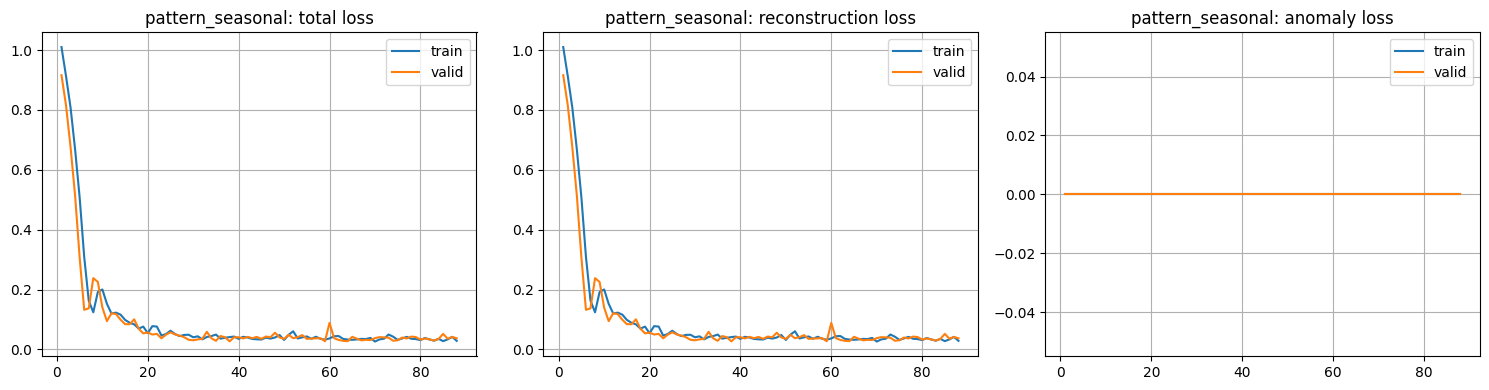

Training PATTERN_SHAPELET dataset...


 49%|███████████████████████████████████████▋                                         | 49/100 [20:44<21:12, 24.95s/it]


Epoch 50 completed:
  Average Total Loss: 0.0153
  Average Recon Loss: 0.0153
  Average Anomaly Loss: 0.0000

Epoch 50 validated:
  Average Total Loss: 0.0105
  Average Recon Loss: 0.0105
  Average Anomaly Loss: 0.0000


 99%|████████████████████████████████████████████████████████████████████████████████▏| 99/100 [41:41<00:25, 25.45s/it]


Epoch 100 completed:
  Average Total Loss: 0.0108
  Average Recon Loss: 0.0108
  Average Anomaly Loss: 0.0000

Epoch 100 validated:
  Average Total Loss: 0.0086
  Average Recon Loss: 0.0086
  Average Anomaly Loss: 0.0000


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [42:07<00:00, 25.28s/it]


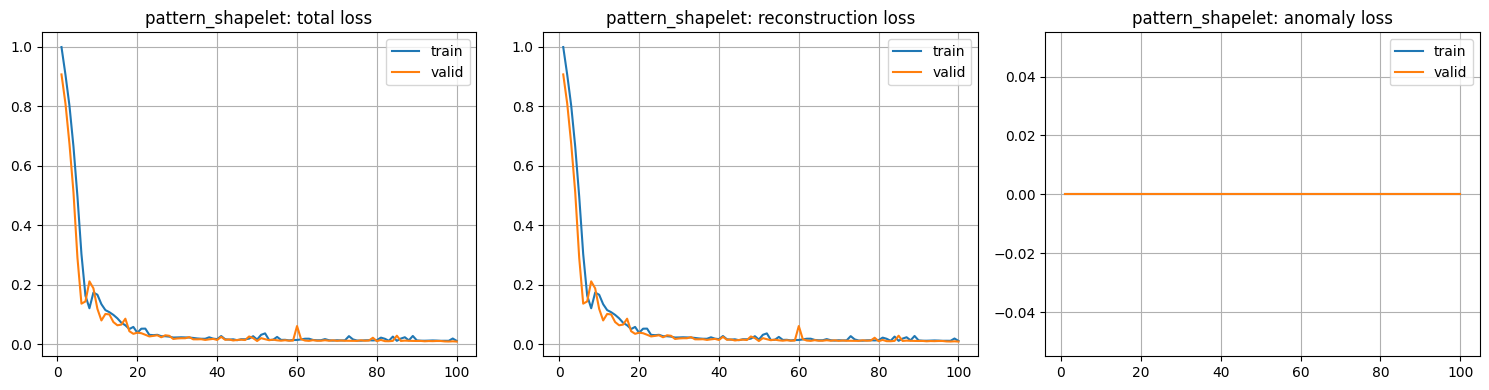

Training PATTERN_TRENDV2 dataset...


 49%|███████████████████████████████████████▋                                         | 49/100 [20:29<21:13, 24.98s/it]


Epoch 50 completed:
  Average Total Loss: 0.0298
  Average Recon Loss: 0.0298
  Average Anomaly Loss: 0.0000

Epoch 50 validated:
  Average Total Loss: 0.0430
  Average Recon Loss: 0.0430
  Average Anomaly Loss: 0.0000


 99%|████████████████████████████████████████████████████████████████████████████████▏| 99/100 [41:22<00:25, 25.14s/it]


Epoch 100 completed:
  Average Total Loss: 0.0179
  Average Recon Loss: 0.0179
  Average Anomaly Loss: 0.0000

Epoch 100 validated:
  Average Total Loss: 0.0762
  Average Recon Loss: 0.0762
  Average Anomaly Loss: 0.0000


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [41:47<00:00, 25.08s/it]


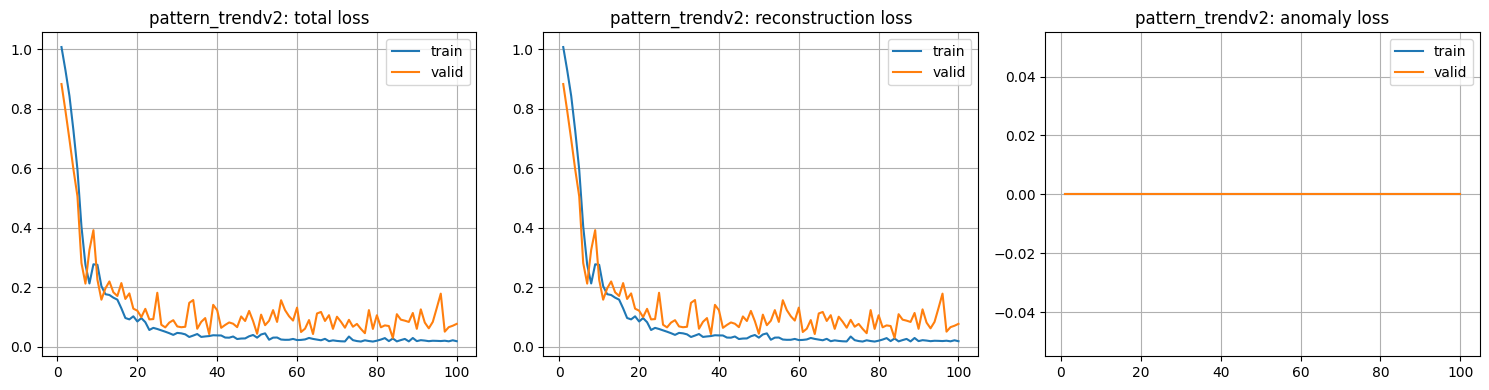

Training POINT_CONTEXTUAL dataset...


 49%|███████████████████████████████████████▋                                         | 49/100 [20:32<21:14, 24.99s/it]


Epoch 50 completed:
  Average Total Loss: 0.0195
  Average Recon Loss: 0.0195
  Average Anomaly Loss: 0.0000

Epoch 50 validated:
  Average Total Loss: 0.0148
  Average Recon Loss: 0.0148
  Average Anomaly Loss: 0.0000


 99%|████████████████████████████████████████████████████████████████████████████████▏| 99/100 [47:38<00:40, 40.18s/it]


Epoch 100 completed:
  Average Total Loss: 0.0141
  Average Recon Loss: 0.0141
  Average Anomaly Loss: 0.0000

Epoch 100 validated:
  Average Total Loss: 0.0123
  Average Recon Loss: 0.0123
  Average Anomaly Loss: 0.0000


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [48:23<00:00, 29.04s/it]


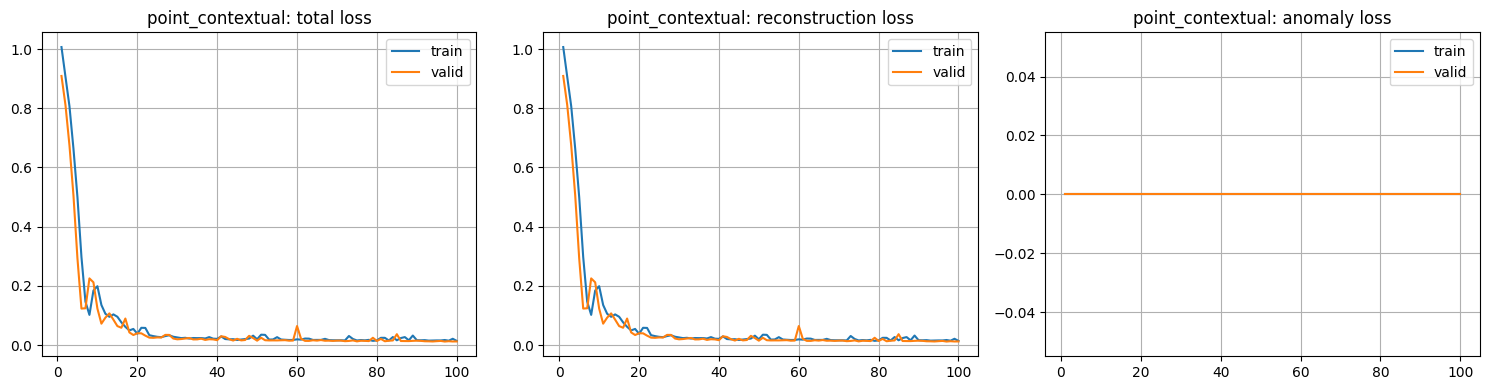

Training POINT_GLOBAL dataset...


 49%|███████████████████████████████████████▋                                         | 49/100 [28:21<30:58, 36.43s/it]


Epoch 50 completed:
  Average Total Loss: 0.0313
  Average Recon Loss: 0.0313
  Average Anomaly Loss: 0.0000

Epoch 50 validated:
  Average Total Loss: 0.0221
  Average Recon Loss: 0.0221
  Average Anomaly Loss: 0.0000


 99%|██████████████████████████████████████████████████████████████████████████████▏| 99/100 [1:01:24<00:42, 42.52s/it]


Epoch 100 completed:
  Average Total Loss: 0.0252
  Average Recon Loss: 0.0252
  Average Anomaly Loss: 0.0000

Epoch 100 validated:
  Average Total Loss: 0.0229
  Average Recon Loss: 0.0229
  Average Anomaly Loss: 0.0000


100%|██████████████████████████████████████████████████████████████████████████████| 100/100 [1:02:06<00:00, 37.27s/it]


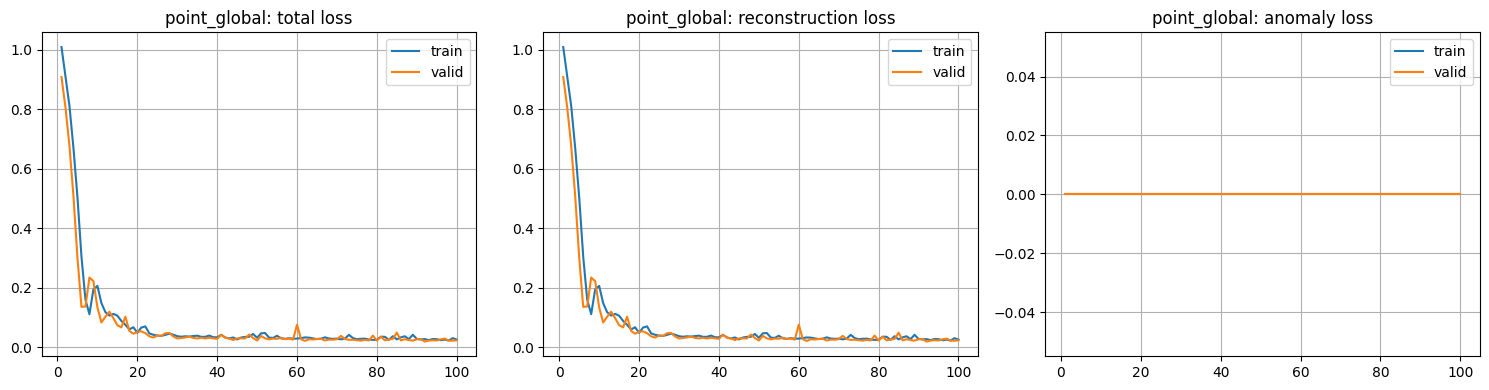

In [13]:
for dataset in loaders:
    print(f"Training {dataset.upper()} dataset...")
    
    tb_writer = init_tensorboard(f"{dataset}/{TIME_NOW}")
    
    train_loader = loaders[dataset]["train"]
    valid_loader = loaders[dataset]["valid"]
    training_config.checkpoint_dir = f"DiffusionAE/{dataset}"

    # Обучаем
    detector = Detector(detector_config)
    losses = train_worker(training_config, detector, train_loader, valid_loader, device=device)
    
    # Логируем лоссы
    plot_training_results(losses, title_prefix=dataset)
    log_losses(tb_writer, losses)

    torch.cuda.empty_cache()
    del detector

## Метрики

In [12]:
from src import benchmark, load_checkpoint
from tensorboard_utils import log_hparams


def benchmark_dataset(dataset, stage):
    print(f"Benchmarking {dataset} dataset...")
    tb_writer = init_tensorboard(f"{dataset}/{TIME_NOW}")

    # Подгружаем чекпоинт
    detector = Detector(detector_config).to(device)
    optimizer = torch.optim.AdamW(
        detector.parameters(),
        lr=training_config.learning_rate,
        weight_decay=training_config.weight_decay
    )
    scaler = torch.amp.GradScaler() if training_config.mixed_precision else None

    training_config.checkpoint_dir = f"DiffusionAE/{dataset}"
    checkpoint_path = f"{training_config.checkpoint_dir}/pretrain_checkpoint_best.pth"
    checkpoint = load_checkpoint(training_config, detector, optimizer, scaler, checkpoint_path, device, strict=True)

    # Логируем конфиги и метрики
    metrics = benchmark(detector, loaders[dataset][stage], device, ANOMALY_KEY)
    if stage != "train":
        log_hparams(tb_writer, detector_config, training_config, metrics)

    print(f"{dataset} metrics:")
    for k, v in metrics.items():
        print(f"{k:<20}:\t{v:.4f}")
    print()


def benchmark_all_datasets(stage):
    for dataset in loaders:
        # try:
        #     benchmark_dataset(dataset, stage)
        # except Exception as e:
        #     print(f"Failed to benchmark {dataset} dataset:\n{e}")
        #     continue
        benchmark_dataset(dataset, stage)

In [13]:
benchmark_all_datasets("valid")

Benchmarking pattern_seasonal dataset...
pattern_seasonal metrics:
RMSE                :	0.2000
MAE                 :	0.1221
AUC-ROC             :	0.9113
F1                  :	0.4619
Precision           :	0.9704
Recall              :	0.3031

Benchmarking pattern_shapelet dataset...
pattern_shapelet metrics:
RMSE                :	0.1449
MAE                 :	0.1116
AUC-ROC             :	0.7281
F1                  :	0.3735
Precision           :	0.9268
Recall              :	0.2338

Benchmarking pattern_trendv2 dataset...
pattern_trendv2 metrics:
RMSE                :	0.2944
MAE                 :	0.1441
AUC-ROC             :	0.8433
F1                  :	0.5116
Precision           :	0.9167
Recall              :	0.3548

Benchmarking point_contextual dataset...
point_contextual metrics:
RMSE                :	0.1579
MAE                 :	0.1199
AUC-ROC             :	0.8435
F1                  :	0.4468
Precision           :	0.9438
Recall              :	0.2927

Benchmarking point_global dataset.

## Визуализация (TODO)

In [14]:
from src import visualize_batch_sample


def show_example(dataset_name):
    detector = Detector(detector_config).to(device)
    optimizer = torch.optim.AdamW(
        detector.parameters(),
        lr=training_config.learning_rate,
        weight_decay=training_config.weight_decay
    )
    scaler = torch.amp.GradScaler() if training_config.mixed_precision else None
    
    checkpoint_path = f"DiffusionAE/{dataset_name}/pretrain_checkpoint_best.pth"
    checkpoint = load_checkpoint(training_config, detector, optimizer, scaler, checkpoint_path, device, strict=True)

    it = iter(loaders[dataset_name]["valid"])
    for _ in range(2):
        batch = next(it)
    visualize_batch_sample(detector, batch, sample_idx=0)

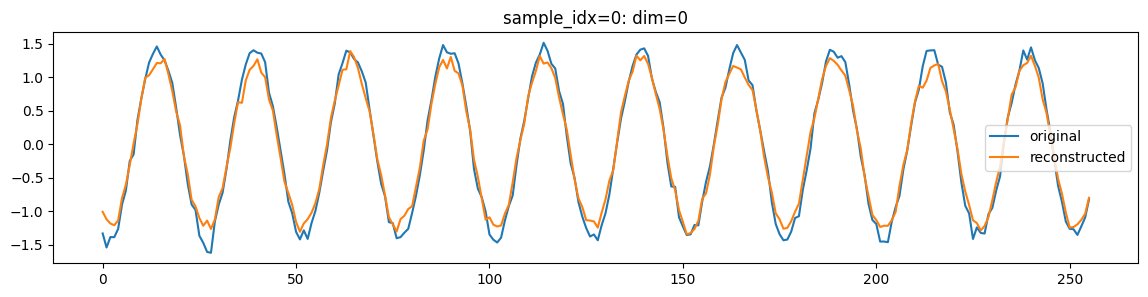

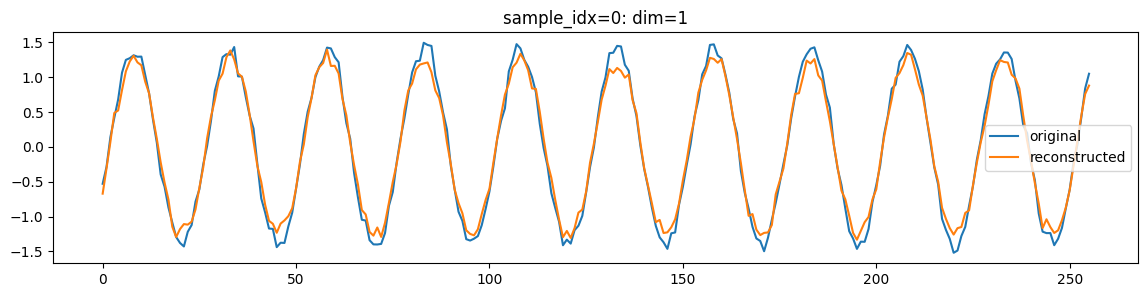

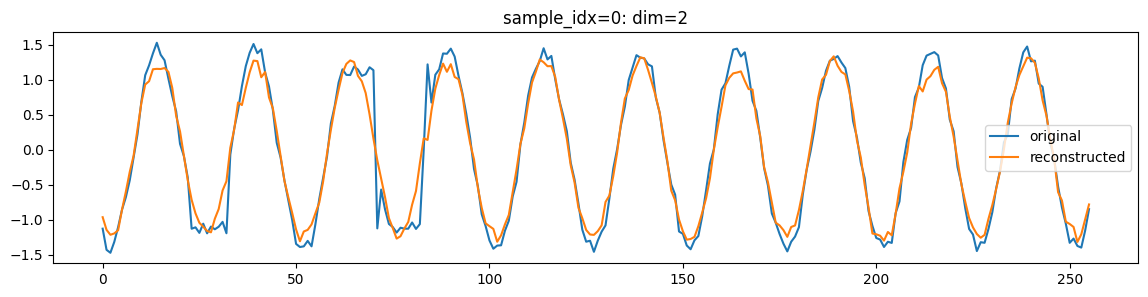

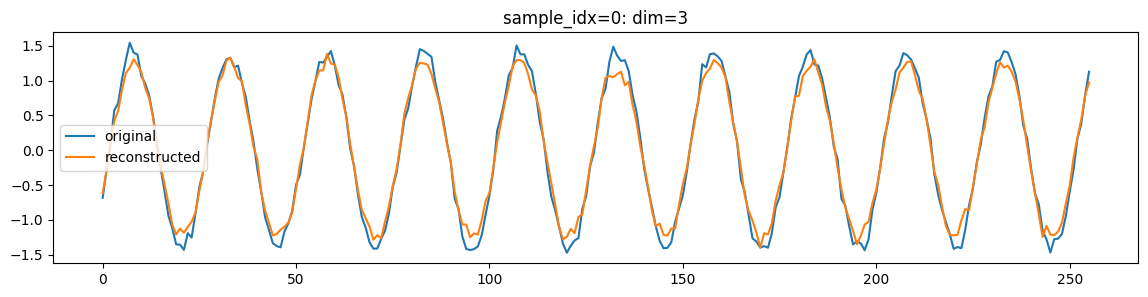

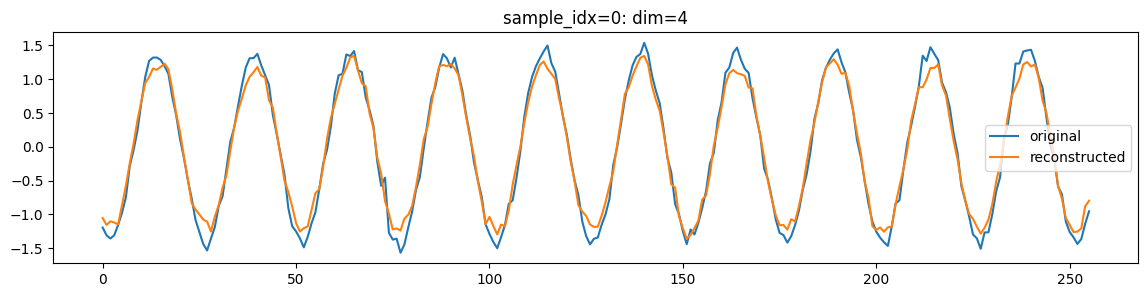

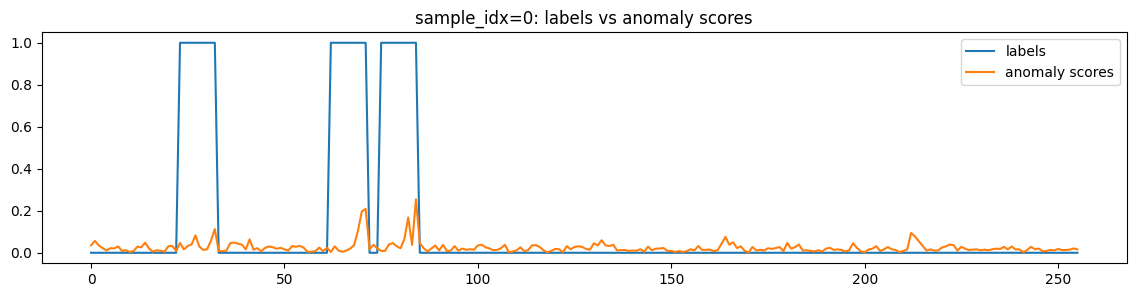

In [15]:
show_example("pattern_shapelet")

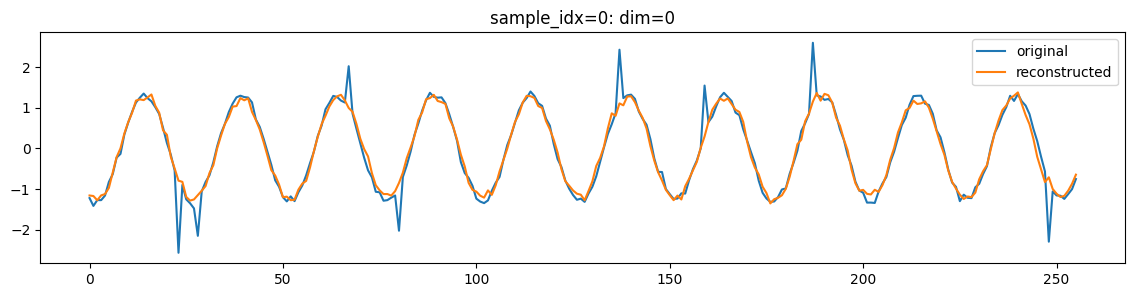

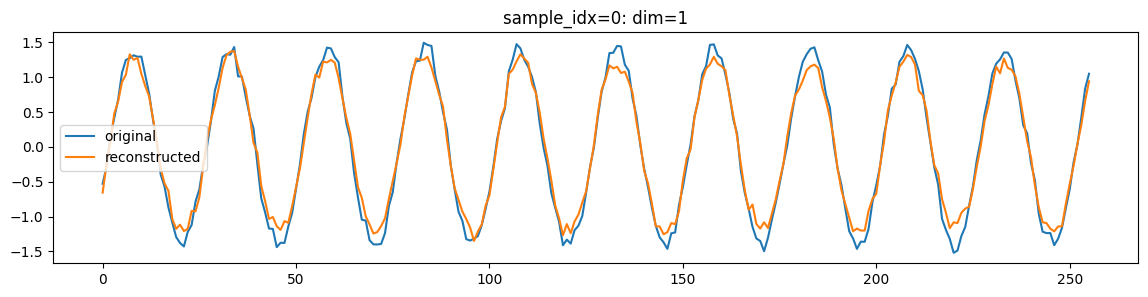

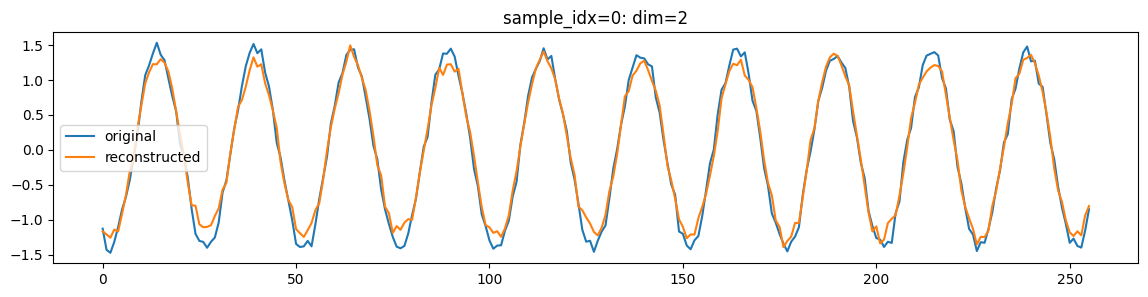

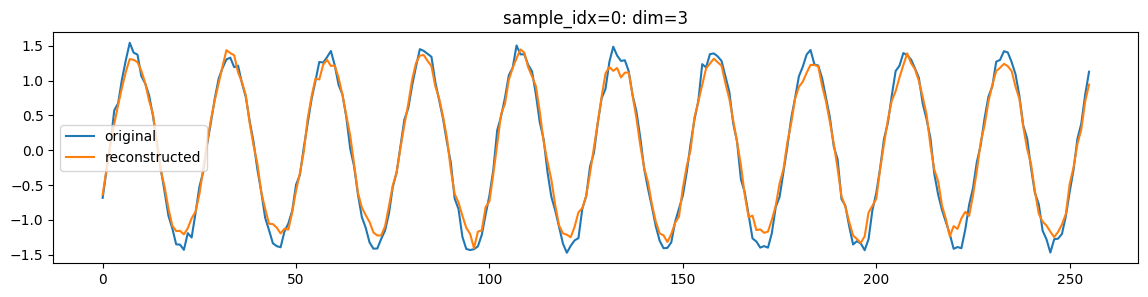

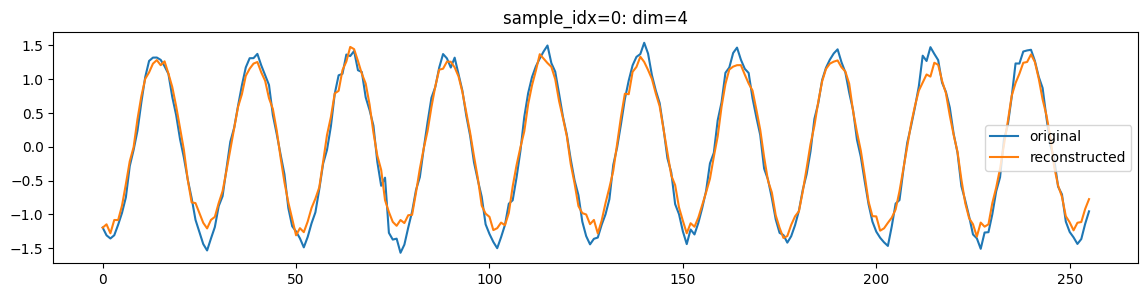

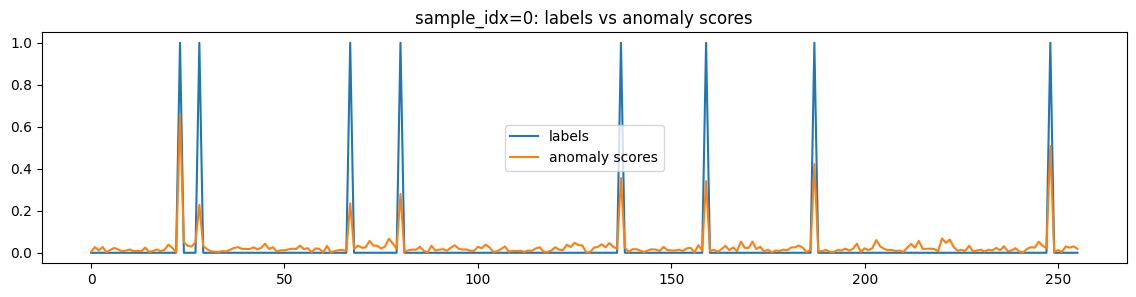

In [16]:
show_example("point_global")

In [17]:
# def visualize_single_sample(results, sample_idx=0, save_path=None):
#     """Visualize results for a single time series sample."""
#     # Extract data for the specified sample
#     original = results['original'][sample_idx].squeeze(-1).numpy()  # (seq_len, num_features) / (seq_len,)
#     masked = results['masked'][sample_idx].squeeze(-1).numpy()
#     reconstructed = results['reconstructed'][sample_idx].squeeze(-1).numpy()
#     mask = results['mask'][sample_idx].numpy().astype(bool)
#     anomaly_probs = results['anomaly_probs'][sample_idx].numpy()  # (seq_len,)
#     true_labels = results['true_labels'][sample_idx].numpy()  # (seq_len,)
#     attention_mask = results['attention_mask'][sample_idx].numpy().astype(bool)

#     # Only consider valid sequence length
#     valid_length = attention_mask.sum()
#     original = original[:valid_length]
#     masked = masked[:valid_length]
#     reconstructed = reconstructed[:valid_length]
#     mask = mask[:valid_length]
#     anomaly_probs = anomaly_probs[:valid_length]
#     true_labels = true_labels[:valid_length]

#     # Create time axis
#     time_axis = np.arange(len(original))

#     assert original.ndim == reconstructed.ndim == masked.ndim, "Original, reconstructed, and masked time series must have the same dimensions."

#     _, num_features = original.shape

#     fig_height = 4 * num_features + 2
#     fig, axes = plt.subplots(num_features, 1, figsize=(16, fig_height))
#     plt.subplots_adjust(top=0.85, hspace=0.2, left=0.08, right=0.92, bottom=0.08)

#     anomaly_regions = []
#     in_anomaly = False
#     start_idx = 0
#     for i, is_anomaly in enumerate(true_labels > 0.5):
#         if is_anomaly and not in_anomaly:
#             start_idx = i
#             in_anomaly = True
#         elif not is_anomaly and in_anomaly:
#             anomaly_regions.append((start_idx, i - 1))
#             in_anomaly = False
#     if in_anomaly:
#         anomaly_regions.append((start_idx, len(true_labels) - 1))

#     for feature_idx in range(num_features):
#         ax = axes[feature_idx]
#         ax.plot(time_axis, original[:, feature_idx], 'b-',
#                 linewidth=1, label=f'Anomalous Time Series', alpha=0.8)
#         # ax.plot(time_axis, normal[:, feature_idx], 'g-',
#         #         linewidth=1, label='Normal Time Series', alpha=0.8)
#         y_min, y_max = ax.get_ylim()
#         shift = y_max - y_min
#         ax.set_ylim(y_min - shift, y_max)

#         for start, end in anomaly_regions:
#             if start == end:
#                 ax.axvspan(start - 0.5, start + 0.5, alpha=0.3, color='grey',
#                            label='True Anomaly Region' if start == anomaly_regions[0][
#                                0] and feature_idx == 0 else "")
#             else:
#                 ax.axvspan(start, end, alpha=0.3, color='grey',
#                            label='True Anomaly Region' if start == anomaly_regions[0][
#                                0] and feature_idx == 0 else "")

#         ax2 = ax.twinx()
#         ax2.plot(time_axis, anomaly_probs, 'r-', linewidth=1,
#                  label='Anomaly Score', alpha=0.9)
#         ax2.set_ylim(0, 1.5)
#         ax2.set_ylabel('Anomaly Score', fontsize=12)
#         ax.set_ylabel(f'Value', fontsize=12)
#         if feature_idx == num_features - 1:
#             ax.set_xlabel('Time Steps', fontsize=12)
#         else:
#             ax.set_xticklabels([])

#         ax.set_title(f'Feature {feature_idx} - Time Series & Anomaly Score',
#                      fontsize=16, pad=10)
#         ax.grid(True, alpha=0.3)

#         if feature_idx == 0:
#             lines1, labels1 = ax.get_legend_handles_labels()
#             lines2, labels2 = ax2.get_legend_handles_labels()
#             ax.legend(lines1 + lines2, labels1 + labels2,
#                       loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=14)

#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#     plt.show()

In [18]:
# pred = predict_batch(detector, batch, device)
# visualize_single_sample(pred, sample_idx=1)